<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/OPCUANetwork_IsolationForest_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Prediction using IsolationForest on OPC UA Network Data**

This notebook demonstrates the development and application of a unsupervised machine model using IsolaionForest from the sklearn libary to perform anomaly prediction on network data generated from between Siemens PLCSimAdvanced and NX MCD during a multi-stage attack simulation. The goal of this task is to identify behaviours related to writing commands to PLC for anomaly scoring.


#Objective of This Notebook

The goal of this notebook is to show the end-to-end process of applying IsolationForest on anomaly detection on network data, including
*   Data Preprocessing for Model Training and Evaluation
*   Model Training
*   Model Evaluation
*   Model Inference on the Multi-Stage Attack Simulated on 9 May 2025



#Background

A multi-stage cyber-physical attack simulation was conducted on 9 May 2025, between 14:34 and 17:02 (UK local time), using a Digital Twin-based testbed replicating a sorting process controlled within Siemens NX MCD. The testbed was integrated with HMI and OPC UA clients to simulate real-world adversarial behaviours targeting industrial actuators.

Out of the five attack steps, Step 3 and Step 5 involved manual manipulations of the physical process:

*   Step 3: Issued unauthorized commands through an HMI via RDP session.
*   Step 5: Executed unauthorized OPC UA write requests from UA Expert to the NX process.

These two steps are expected to exhibit anomalous write commands detectable in the network data. In contrast, Steps 1, 2, and 4 involved activities confined to host and TCP/IP network layers (e.g., discovery, lateral movement) and thus do not influence the OPC UA network state directly.

The goal is using unsupervised learning (IsolationForest) to identify write behaviours for anomaly scoring.  

#Overview of the Anomaly Detection Model

For anomaly detection, we have identified 5 different scenarios in the NX scene. It could be a normal scenarios or threat scenarios. The scenario (being the label (y) to be predicted) include:
*   Label #0 - 'Normal_NoIntervention': Baseline operation without intervention.
*   Label #1 - 'Conveyor_SpeedManipulation':Speed forcibly reduced from standard (e.g., 300 to 50, or 50 to 10).
*   Label #2 - 'Gripper_SuctionForceRelease': Suction signal changed from 1 (hold) to 0 (release).
*   Label #3 - 'Gripper_ZAxisDirectionManipulation': Reverses Z-axis movement by forcing -400 (downward) instead of +400 (upward), and vice versa.
*   Label #4 - 'Gripper_RotationDeviation': Rotation angle forced to inappropriate value (e.g., 0° to 360°).
*   Label #5 - Multi-vector attacks of the above scenarios

Label 1 to 5 consists of threat scenarios that relate to using OPC UA Client via HMI or UA Expert, simulating attacker using Living off the Land techniques to abuse native tools in victim environment.

#Simulation Process

For each scenario, we have carried out 10 simulation runs (i.e. 10 instances for each label). Therefore, there are tototally 60 simulation instances in the form of pcapng. Each packet contains roughly 1 minute of simulation.

The instance for Label #0 are used for model training, the instances for Label #1 to #5 are used for model evaluation.

#Data Capture Process

During the simulation run, we used Wireshark to collect network packet data between the OPC UA Server and OPC UA Client.

The entire packet capture file (.pcapng with 538,898 packets) contains OPC UA traffic on 9 May 2025 from 14:34 to 17:06 (local time, London/UK). The packet capture is analysed using Zeek with OPC UA Plug-in. The output file named 'opcua_binary.log' and 'opcua_binary_write.log' generated by Zeek are used for predictive analytics.

Specificially, most of the data from 'opcua_binary.log' are the core information for model training. The enrich the dataset with better explainability, the corresponding 'opcua_binary_write.log' are correlated via linking the 'opcua_link_id' to obtain relevant semantic context, including the value in 'node_id_string' and 'req_status_code_link_id'.

We have used several python scripts to preprocess the .log file into .csv file, prepared to right format and extracted the features. The data preprocessing stage (Step 2) in this noebook focuses on aggregate features for each 1-minute network traffic, and then use these information for model training, evaluation and inference.

#Step 0 - Check GPU

To speed up the model training process, GPU is used.

In [1]:
# Turn on GPU T4

# Runtime > Change runtime type

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon May 12 09:48:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Step 1 - File upload

In [2]:
# Upload csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded['opcua_instance1-60_sliced_1min.csv']))
# df1 = pd.read_csv(io.BytesIO(uploaded['20250509_Network_OPCUA_enriched_features_instanced_file1.csv']))
# df2 = pd.read_csv(io.BytesIO(uploaded['20250509_Network_OPCUA_enriched_features_instanced_file2.csv']))

print("The number of rows and columns in the csv file: ", df.shape)
#print("The number of rows and columns in the csv file 1: ", df1.shape)
#print("The number of rows and columns in the csv file 2: ", df2.shape)

Saving opcua_instance1-60_sliced_1min.csv to opcua_instance1-60_sliced_1min.csv
The number of rows and columns in the csv file:  (439436, 13)


60 instances with varied number of rows for each instance, expected number of row is 439,436 (enriched with the opcua_binary_write.log, in particular the 'node_id_string' is added.)

opcua_binary_write.log adds essential depth, capturing write-level interactions previously absent in the plain opcua_binary.log. The sementic information should add explainability to operators.

In [3]:
# Display the first few rows of the dataframe to check file format
df.head()

,instance,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,is_orig,opcua_link_id,is_final,msg_size,identifier,node_id_string
0,1,2025-03-27 20:27:40.714514971,Cmy2664WAJ1oJggPJh,10.12.25.3,62569,10.12.25.30,4840,T,5f4b1116c3941bc85a,F,253,673.0,-
1,1,2025-03-27 20:27:40.714514971,Cmy2664WAJ1oJggPJh,10.12.25.3,62569,10.12.25.30,4840,T,5f4b1116c3941bc85a,F,253,673.0,-
2,1,2025-03-27 20:27:40.714514971,Cmy2664WAJ1oJggPJh,10.12.25.3,62569,10.12.25.30,4840,T,5f4b1116c3941bc85a,F,253,673.0,-
3,1,2025-03-27 20:27:40.714514971,Cmy2664WAJ1oJggPJh,10.12.25.3,62569,10.12.25.30,4840,T,5f4b1116c3941bc85a,F,253,673.0,-
4,1,2025-03-27 20:27:40.714514971,Cmy2664WAJ1oJggPJh,10.12.25.3,62569,10.12.25.30,4840,T,5f4b1116c3941bc85a,F,253,673.0,-


Regarding the columns on the dataset:

*   'instance' is instance identifier. There are 60 instance in this dataset.
*   'ts' is the timestamp for each instance.
*   'uid' is the unique connection identifier assigned by Zeek for correlating bidirectional flows.
*   'id.orig_h' is the source IP address (OPC UA Client)
*   'id.orig_p' is the source IP port
*   'id.resp_h' is the destination IP address (OPC UA Server)
*   'id.resp_p' is the destination IP port
*   'is_orig' is the message originator
*   'opcua_link_id' is the key to link among zeek logs
*   'is_final' is the message is completed or fragmented
*   'msg_size' is the size of OPC UA message in bytes
*   'identifier' is the message type of OPC UA
*   'node_id_string' indicate what is the write command detected (human-readable)

# Step 2 - Dataset Preprocessing and Feature Extraction for Instance-level Anomaly Detection (1 minute per instance)

In [4]:
# Timestamp
df['ts'] = pd.to_datetime(df['ts'], errors='coerce')

# Use source port to distinguish between HMI, UA Expert or PLC (automated activity)
df['id.orig_p'] = pd.to_numeric(df['id.orig_p'], errors='coerce')

#  Binary encode for message initiator (OPC UA client / message request = 1; OPC UA server / message responder = 0)
if df['is_orig'].dtype == 'object':
    df['is_orig'] = df['is_orig'].astype(str).str.strip().str.upper().map({'T': 1, 'F': 0})

#  Binary encode for message status (Complete message = 1; Incomplete message = 0)
if df['is_final'].dtype == 'object':
    df['is_final'] = df['is_final'].astype(str).str.strip().str.upper().map({'T': 1, 'F': 0})

In [5]:
# Convert identifier to numeric, drop invalid rows
df = df[df['identifier'] != '-'].copy()
df['identifier'] = pd.to_numeric(df['identifier'], errors='coerce')
df.dropna(subset=['identifier'], inplace=True)
df['identifier'] = df['identifier'].astype('Int64')

# Ensure msg_size is numeric
df['msg_size'] = pd.to_numeric(df['msg_size'], errors='coerce')

In [6]:
# Create semantic flag for write operations
df['is_WriteOps'] = (df['identifier'] == 673).astype(int)

# Define most common message size used for write ops
common_write_size = df[df['identifier'] == 673]['msg_size'].mode().iloc[0]

# Binary flag for anomalies in write operation size
df['write_msg_anomaly'] = ((df['identifier'] == 673) & (df['msg_size'] != common_write_size)).astype(int)

In [7]:
# Count unique write targets per instance (e.g., Conveyor1_Speed, Gripper_ZPos, etc.)
df['node_id_string_clean'] = df['node_id_string'].fillna('-').astype(str).str.strip()
df['is_valid_node'] = (df['node_id_string_clean'] != '-').astype(int)

# Count how many different write targets were touched in each instance
# unique_node_target_count captures how many different write targets (e.g., Conveyor1_Speed) were accessed per instance.
# Only non-empty values from 'node_id_string' are counted, implicitly tied to identifier == 673 (WriteRequest).
unique_node_counts = df[df['is_valid_node'] == 1].groupby('instance')['node_id_string_clean'].nunique().reset_index()
unique_node_counts = unique_node_counts.rename(columns={'node_id_string_clean': 'unique_node_target_count'})


In [8]:
# Merge the unique node count back into the main dataframe before aggregation
df = pd.merge(df, unique_node_counts, on='instance', how='left')
df = pd.merge(df, unique_node_counts.rename(columns={'unique_node_target_count': 'unique_write_targets'}), on='instance', how='left')

# Aggregate features for each instance
instance_summary = df.groupby('instance').agg({
    'write_msg_anomaly': ['sum', 'mean'],
    'is_WriteOps': ['sum', 'mean'],
    'msg_size': 'count',
    'unique_write_targets': 'first' # CHANGE 'count' to 'first'
})

# Flatten column names
instance_summary.columns = ['_'.join(col).strip() for col in instance_summary.columns]

instance_summary = instance_summary.rename(columns={
    'write_msg_anomaly_sum': 'write_anomaly_count',
    'write_msg_anomaly_mean': 'write_anomaly_ratio',
    'is_WriteOps_sum': 'write_ops_count',
    'is_WriteOps_mean': 'write_ops_ratio',
    'msg_size_count': 'total_packets',
    'unique_write_targets_first': 'unique_write_targets_count'
}).reset_index()

In [9]:
# Rename in instance_summary
instance_summary = instance_summary.rename(columns={
    'unique_node_target_count_count': 'unique_write_targets'
})

In [10]:
# Display the first few rows of the dataframe to check file format
instance_summary.head()

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count
0,1,0,0.0,5840,0.753646,7749,NaN
1,2,0,0.0,5140,0.752783,6828,NaN
2,3,0,0.0,5830,0.753619,7736,NaN
3,4,0,0.0,5720,0.753623,7590,NaN
4,5,0,0.0,5400,0.753453,7167,NaN


In [11]:
print(instance_summary.columns)

Index(['instance', 'write_anomaly_count', 'write_anomaly_ratio',
       'write_ops_count', 'write_ops_ratio', 'total_packets',
       'unique_write_targets_count'],
      dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439436 entries, 0 to 439435
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   instance                  439436 non-null  int64         
 1   ts                        439436 non-null  datetime64[ns]
 2   uid                       439436 non-null  object        
 3   id.orig_h                 439436 non-null  object        
 4   id.orig_p                 439436 non-null  int64         
 5   id.resp_h                 439436 non-null  object        
 6   id.resp_p                 439436 non-null  int64         
 7   is_orig                   439436 non-null  int64         
 8   opcua_link_id             439436 non-null  object        
 9   is_final                  439436 non-null  int64         
 10  msg_size                  439436 non-null  int64         
 11  identifier                439436 non-null  Int64         
 12  no

# Step 3 - Train the Model

In [13]:
# Features to use
features_for_iforest = ['write_anomaly_count', 'write_anomaly_ratio', 'write_ops_ratio', 'unique_write_targets_count']

In [14]:
# Use normal instances 1–10 to train baseline
X_train = instance_summary[instance_summary['instance'] <= 10][features_for_iforest]
X_all = instance_summary[features_for_iforest]

In [15]:
# Fit the model
from sklearn.ensemble import IsolationForest

iso_005 = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_01 = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iso_015 = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
iso_02 = IsolationForest(n_estimators=100, contamination=0.2, random_state=42)
iso_025 = IsolationForest(n_estimators=100, contamination=0.25, random_state=42)
iso_03 = IsolationForest(n_estimators=100, contamination=0.3, random_state=42)
iso_035 = IsolationForest(n_estimators=100, contamination=0.35, random_state=42)

iso_005.fit(X_train)
iso_01.fit(X_train)
iso_015.fit(X_train)
iso_02.fit(X_train)
iso_025.fit(X_train)
iso_03.fit(X_train)
iso_035.fit(X_train)

IsolationForest(contamination=0.35, random_state=42)

#Step 4 - Model Evaluation and Performance Analysis on All 60 Instances (Model Optimisation)

In [16]:
# Predict anomaly scores
instance_summary['anomaly_score_0.05'] = iso_005.decision_function(X_all)
instance_summary['anomaly_0.05'] = iso_005.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.1'] = iso_01.decision_function(X_all)
instance_summary['anomaly_0.1'] = iso_01.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.15'] = iso_015.decision_function(X_all)
instance_summary['anomaly_0.15'] = iso_015.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.2'] = iso_02.decision_function(X_all)
instance_summary['anomaly_0.2'] = iso_02.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.25'] = iso_025.decision_function(X_all)
instance_summary['anomaly_0.25'] = iso_025.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.3'] = iso_03.decision_function(X_all)
instance_summary['anomaly_0.3'] = iso_03.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.35'] = iso_035.decision_function(X_all)
instance_summary['anomaly_0.35'] = iso_035.predict(X_all)  # -1 = anomaly

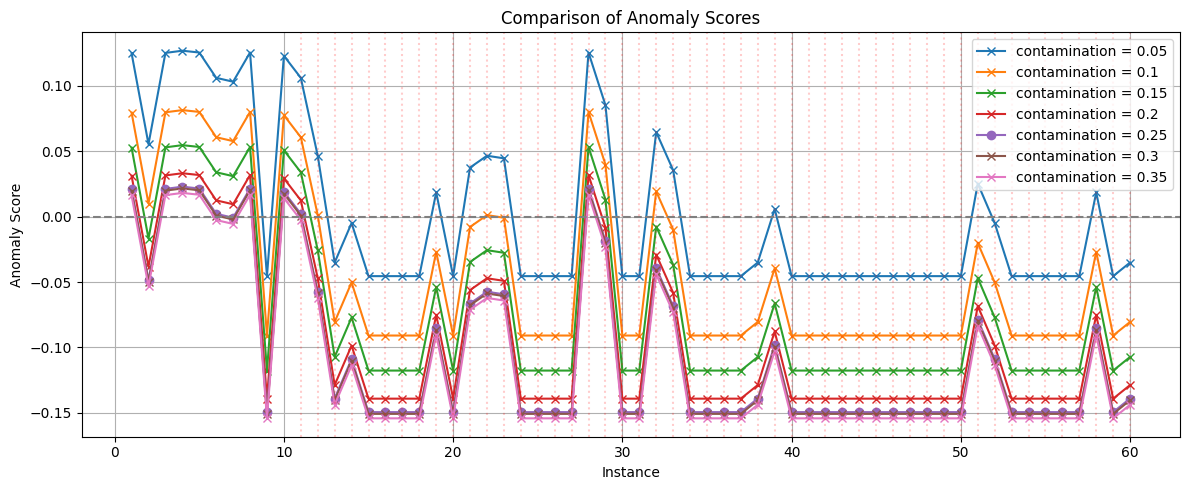

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.05'], label='contamination = 0.05', marker='x')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.1'], label='contamination = 0.1', marker='x')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.15'], label='contamination = 0.15', marker='x')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.2'], label='contamination = 0.2', marker='x')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.25'], label='contamination = 0.25', marker='o')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.3'], label='contamination = 0.3', marker='x')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.35'], label='contamination = 0.35', marker='x')
plt.axhline(0, color='gray', linestyle='--')

for attack_instance in range(11, 61):
    plt.axvline(x=attack_instance, color='red', linestyle=':', alpha=0.2)

plt.xlabel('Instance')
plt.ylabel('Anomaly Score')
plt.title('Comparison of Anomaly Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# Create ground truth column
instance_summary['label'] = (instance_summary['instance'] > 10).astype(int)  # 0 = normal, 1 = attack

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
y_true = instance_summary['label']

# For contamination = 0.05
y_pred_005 = (instance_summary['anomaly_0.05'] == -1).astype(int)
print("=== Contamination 0.05 ===")
print(confusion_matrix(y_true, y_pred_005))
print(classification_report(y_true, y_pred_005))

# For contamination = 0.1
y_pred_01 = (instance_summary['anomaly_0.1'] == -1).astype(int)
print("=== Contamination 0.1 ===")
print(confusion_matrix(y_true, y_pred_01))
print(classification_report(y_true, y_pred_01))

# For contamination = 0.15
y_pred_015 = (instance_summary['anomaly_0.15'] == -1).astype(int)
print("=== Contamination 0.15 ===")
print(confusion_matrix(y_true, y_pred_015))
print(classification_report(y_true, y_pred_015))

# For contamination = 0.2
y_pred_02 = (instance_summary['anomaly_0.2'] == -1).astype(int)
print("=== Contamination 0.2 ===")
print(confusion_matrix(y_true, y_pred_02))
print(classification_report(y_true, y_pred_02))

# For contamination = 0.25
y_true = instance_summary['label']
y_pred_025 = (instance_summary['anomaly_0.25'] == -1).astype(int)
print("=== Contamination 0.25 ===")
print(confusion_matrix(y_true, y_pred_025))
print(classification_report(y_true, y_pred_025))

# For contamination = 0.3
y_true = instance_summary['label']
y_pred_03 = (instance_summary['anomaly_0.3'] == -1).astype(int)
print("=== Contamination 0.3 ===")
print(confusion_matrix(y_true, y_pred_03))
print(classification_report(y_true, y_pred_03))

# For contamination = 0.35
y_true = instance_summary['label']
y_pred_035 = (instance_summary['anomaly_0.35'] == -1).astype(int)
print("=== Contamination 0.35 ===")
print(confusion_matrix(y_true, y_pred_035))
print(classification_report(y_true, y_pred_035))

=== Contamination 0.05 ===
[[ 9  1]
 [13 37]]
              precision    recall  f1-score   support

           0       0.41      0.90      0.56        10
           1       0.97      0.74      0.84        50

    accuracy                           0.77        60
   macro avg       0.69      0.82      0.70        60
weighted avg       0.88      0.77      0.79        60

=== Contamination 0.1 ===
[[ 9  1]
 [ 6 44]]
              precision    recall  f1-score   support

           0       0.60      0.90      0.72        10
           1       0.98      0.88      0.93        50

    accuracy                           0.88        60
   macro avg       0.79      0.89      0.82        60
weighted avg       0.91      0.88      0.89        60

=== Contamination 0.15 ===
[[ 8  2]
 [ 3 47]]
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.96      0.94      0.95        50

    accuracy                           0.92  

Precision (how many flagged as anomalies are truly attacks)

Recall (how many true attacks were detected)

F1 score (balance)

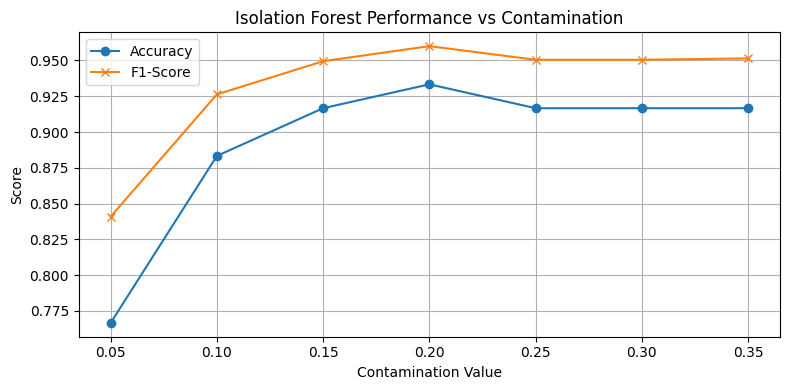

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Example contamination values and their corresponding F1-scores or accuracy
contamination_vals = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35]
f1_scores = []
accuracy_vals = []

for cont in contamination_vals:
    y_pred = (instance_summary[f'anomaly_{cont}'] == -1).astype(int)
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1_scores.append(f1)
    accuracy_vals.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(contamination_vals, accuracy_vals, marker='o', label='Accuracy')
plt.plot(contamination_vals, f1_scores, marker='x', label='F1-Score')
plt.title('Isolation Forest Performance vs Contamination')
plt.xlabel('Contamination Value')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**With this empirical study, contamination = 0.2 is chosen as it is an optimal value based on F1-score on the evaluation set**

In [21]:
summary = pd.DataFrame({
    'Instance': instance_summary['instance'],
    'Label': instance_summary['label'],
    'Score_0.2': instance_summary['anomaly_score_0.2'],
    'Anomaly_0.2': y_pred_02,
})
display(summary.head(20))

,Instance,Label,Score_0.2,Anomaly_0.2
0,1,0,0.031338,0
1,2,0,-0.038184,1
2,3,0,0.031587,0
3,4,0,0.033266,0
4,5,0,0.031886,0
5,6,0,0.012531,0
6,7,0,0.009546,0
7,8,0,0.031886,0
8,9,0,-0.139128,1
9,10,0,0.029358,0


In [22]:
# Ensure missing node_id_string values are excluded
df_valid_nodes = df[df['node_id_string'] != '-']

# Get the most frequent node_id_string per instance
dominant_node_per_instance = (
    df_valid_nodes.groupby(['instance', 'node_id_string'])
    .size()
    .reset_index(name='count')
    .sort_values(['instance', 'count'], ascending=[True, False])
    .drop_duplicates(subset=['instance'])
    .rename(columns={'node_id_string': 'dominant_node'})
    [['instance', 'dominant_node']]
)

# Merge into instance_summary
instance_summary = pd.merge(instance_summary, dominant_node_per_instance, on='instance', how='left')

In [23]:
display(instance_summary[['instance', 'write_anomaly_count', 'write_anomaly_ratio',
                          'write_ops_count', 'write_ops_ratio', 'total_packets',
                          'anomaly_score_0.2', 'label', 'dominant_node']])

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,anomaly_score_0.2,label,dominant_node
0,1,0,0.000000,5840,0.753646,7749,0.031338,0,NaN
1,2,0,0.000000,5140,0.752783,6828,-0.038184,0,NaN
2,3,0,0.000000,5830,0.753619,7736,0.031587,0,NaN
3,4,0,0.000000,5720,0.753623,7590,0.033266,0,NaN
4,5,0,0.000000,5400,0.753453,7167,0.031886,0,NaN
5,6,0,0.000000,5900,0.753801,7827,0.012531,0,NaN
6,7,0,0.000000,5690,0.753243,7554,0.009546,0,NaN
7,8,0,0.000000,5840,0.753451,7751,0.031886,0,NaN
8,9,0,0.000000,5760,0.749317,7687,-0.139128,0,NaN
9,10,0,0.000000,5760,0.753434,7645,0.029358,0,NaN


The resulting .csv file will be used for decision fusion with process data generated from Siemens NX MCD.

In [24]:
instance_summary.to_csv("instance_anomaly_summary_02.csv", index=False)

In [25]:
import pickle

# Save the trained Isolation Forest model
with open('iso_forest_025.pkl', 'wb') as f:
    pickle.dump(iso_025, f)

print("Model saved as iso_forest_025.pkl")

Model saved as iso_forest_025.pkl


In [26]:
import pickle

# Save the trained Isolation Forest model
with open('iso_forest_02.pkl', 'wb') as f:
    pickle.dump(iso_02, f)

print("Model saved as iso_forest_02.pkl")

Model saved as iso_forest_02.pkl


In [27]:
import pickle

# Save the trained Isolation Forest model
with open('iso_forest_015.pkl', 'wb') as f:
    pickle.dump(iso_015, f)

print("Model saved as iso_forest_015.pkl")

Model saved as iso_forest_015.pkl


In [28]:
import pickle

# Save the trained Isolation Forest model
with open('iso_forest_01.pkl', 'wb') as f:
    pickle.dump(iso_01, f)

print("Model saved as iso_forest_01.pkl")

Model saved as iso_forest_01.pkl


#Step 5 - Model Inference on the Multi-Stage Attack Simulated on 9 May 2025

The attack simulation is conducted in the following timeframe.

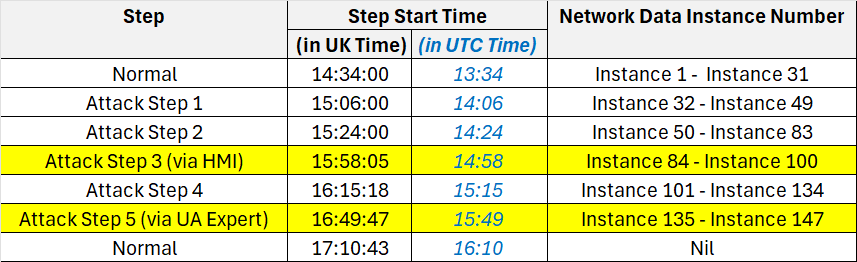

#File Upload

Upload two csv files - 20250509_Network_OPCUA_enriched_features_instanced_file1.csv and 20250509_Network_OPCUA_enriched_features_instanced_file2.csv

In [29]:
# Upload csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

# df = pd.read_csv(io.BytesIO(uploaded['opcua_instance1-60_sliced_1min.csv']))
df1 = pd.read_csv(io.BytesIO(uploaded['20250509_Network_OPCUA_enriched_features_instanced_file1.csv']))
df2 = pd.read_csv(io.BytesIO(uploaded['20250509_Network_OPCUA_enriched_features_instanced_file2.csv']))

#print("The number of rows and columns in the csv file: ", df.shape)
print("The number of rows and columns in the csv file 1: ", df1.shape)
print("The number of rows and columns in the csv file 2: ", df2.shape)

Saving 20250509_Network_OPCUA_enriched_features_instanced_file1.csv to 20250509_Network_OPCUA_enriched_features_instanced_file1.csv
Saving 20250509_Network_OPCUA_enriched_features_instanced_file2.csv to 20250509_Network_OPCUA_enriched_features_instanced_file2.csv
The number of rows and columns in the csv file 1:  (605943, 14)
The number of rows and columns in the csv file 2:  (519478, 14)


<ipython-input-29-a9891a039e1e>:12: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(io.BytesIO(uploaded['20250509_Network_OPCUA_enriched_features_instanced_file2.csv']))


Expected number of rows are


*   The number of rows and columns in file 1 is 605,943, with 14 columns.
*   The number of rows and columns in file 2 is 519,478, with 14 columns.





In [30]:
# Display the first few rows of the dataframe to check file format
df1.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,is_orig,opcua_link_id,is_final,msg_size,identifier,node_id_string,ts_uk,instance
0,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
1,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
2,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
3,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
4,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1


In [31]:
# Display the first few rows of the dataframe to check file format
df2.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,is_orig,opcua_link_id,is_final,msg_size,identifier,node_id_string,ts_uk,instance
0,2025-05-09 14:55:00.013787985,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,18bf492cba4f68f757,F,253,673,-,2025-05-09 15:55:00.013787985+01:00,81
1,2025-05-09 14:55:00.013787985,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,18bf492cba4f68f757,F,253,673,-,2025-05-09 15:55:00.013787985+01:00,81
2,2025-05-09 14:55:00.013787985,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,18bf492cba4f68f757,F,253,673,-,2025-05-09 15:55:00.013787985+01:00,81
3,2025-05-09 14:55:00.013787985,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,18bf492cba4f68f757,F,253,673,-,2025-05-09 15:55:00.013787985+01:00,81
4,2025-05-09 14:55:00.013787985,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,18bf492cba4f68f757,F,253,673,-,2025-05-09 15:55:00.013787985+01:00,81


In [32]:
df_09May = pd.concat([df1, df2], ignore_index=True)

In [33]:
print("Combined dataframe shape:", df_09May.shape)
df_09May.head()

Combined dataframe shape: (1125421, 14)


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,is_orig,opcua_link_id,is_final,msg_size,identifier,node_id_string,ts_uk,instance
0,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
1,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
2,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
3,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
4,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1


In [34]:
df_09May

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,is_orig,opcua_link_id,is_final,msg_size,identifier,node_id_string,ts_uk,instance
0,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
1,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
2,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
3,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
4,2025-05-09 13:35:00.074764013,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,T,d111ed1f4992dc2636,F,253,673,-,2025-05-09 14:35:00.074764013+01:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1125416,2025-05-09 16:02:04.304986954,CdovMV1WK1pJIzJqLi,10.12.25.3,53373,10.12.25.30,4840,F,b4d601f93fb6a74c62,F,74,634,NaN,2025-05-09 17:02:04.304986954+01:00,148
1125417,2025-05-09 16:02:04.307475090,CHEJdfvIL4YU3ks5f,10.12.25.3,53218,10.12.25.30,4840,F,1622f15e06c2f65333,F,1582,829,NaN,2025-05-09 17:02:04.307475090+01:00,148
1125418,2025-05-09 16:02:04.310450077,CHEJdfvIL4YU3ks5f,10.12.25.3,53218,10.12.25.30,4840,T,017ca51c01534df426,F,74,826,NaN,2025-05-09 17:02:04.310450077+01:00,148
1125419,2025-05-09 16:02:05.316029072,CHEJdfvIL4YU3ks5f,10.12.25.3,53218,10.12.25.30,4840,F,1d7d601f3d641c908e,F,1582,829,NaN,2025-05-09 17:02:05.316029072+01:00,148


##Dataset Preprocessing and Feature Extraction for Instance-Level Anomaly Detection

Each instance is already pre-processing using separate scripts to maintain 1 minute per instance.

In [35]:
# Timestamp
df_09May['ts'] = pd.to_datetime(df_09May['ts'], errors='coerce')

# Use source port to distinguish between HMI, UA Expert or PLC (automated activity)
df_09May['id.orig_p'] = pd.to_numeric(df_09May['id.orig_p'], errors='coerce')

#  Binary encode for message initiator (OPC UA client / message request = 1; OPC UA server / message responder = 0)
if df_09May['is_orig'].dtype == 'object':
    df_09May['is_orig'] = df_09May['is_orig'].astype(str).str.strip().str.upper().map({'T': 1, 'F': 0})

#  Binary encode for message status (Complete message = 1; Incomplete message = 0)
if df_09May['is_final'].dtype == 'object':
    df_09May['is_final'] = df_09May['is_final'].astype(str).str.strip().str.upper().map({'T': 1, 'F': 0})

In [36]:
# Convert identifier to numeric, drop invalid rows
df_09May = df_09May[df_09May['identifier'] != '-'].copy()
df_09May['identifier'] = pd.to_numeric(df_09May['identifier'], errors='coerce')
df_09May.dropna(subset=['identifier'], inplace=True)
df_09May['identifier'] = df_09May['identifier'].astype('Int64')

# Ensure msg_size is numeric
df_09May['msg_size'] = pd.to_numeric(df_09May['msg_size'], errors='coerce')

In [37]:
# Create semantic flag for write operations
df_09May['is_WriteOps'] = (df_09May['identifier'] == 673).astype(int)

# Define most common message size used for write ops
common_write_size_09May = df_09May[df_09May['identifier'] == 673]['msg_size'].mode().iloc[0]

# Binary flag for anomalies in write operation size
df_09May['write_msg_anomaly'] = ((df_09May['identifier'] == 673) & (df_09May['msg_size'] != common_write_size_09May)).astype(int)

In [38]:
# Count unique write targets per instance (e.g., Conveyor1_Speed, Gripper_ZPos, etc.)
df_09May['node_id_string_clean'] = df_09May['node_id_string'].fillna('-').astype(str).str.strip()
df_09May['is_valid_node'] = (df_09May['node_id_string_clean'] != '-').astype(int)

# Count how many different write targets were touched in each instance
# unique_node_target_count captures how many different write targets (e.g., Conveyor1_Speed) were accessed per instance.
# Only non-empty values from 'node_id_string' are counted, implicitly tied to identifier == 673 (WriteRequest).
unique_node_counts_09May = df_09May[df_09May['is_valid_node'] == 1].groupby('instance')['node_id_string_clean'].nunique().reset_index()
unique_node_counts_09May = unique_node_counts_09May.rename(columns={'node_id_string_clean': 'unique_node_target_count'})


In [39]:
# Merge the unique node count back into the main dataframe before aggregation
df_09May = pd.merge(df_09May, unique_node_counts_09May, on='instance', how='left')
df_09May = pd.merge(df_09May, unique_node_counts_09May.rename(columns={'unique_node_target_count': 'unique_write_targets'}), on='instance', how='left')


In [40]:
# Aggregate features for each instance
instance_summary_09May = df_09May.groupby('instance').agg({
    'write_msg_anomaly': ['sum', 'mean'],
    'is_WriteOps': ['sum', 'mean'],
    'msg_size': 'count',
    'unique_write_targets': 'first' # CHANGE 'count' to 'first'
})

# Flatten column names
instance_summary_09May.columns = ['_'.join(col).strip() for col in instance_summary_09May.columns]

instance_summary_09May = instance_summary_09May.rename(columns={
    'write_msg_anomaly_sum': 'write_anomaly_count',
    'write_msg_anomaly_mean': 'write_anomaly_ratio',
    'is_WriteOps_sum': 'write_ops_count',
    'is_WriteOps_mean': 'write_ops_ratio',
    'msg_size_count': 'total_packets',
    'unique_write_targets_first': 'unique_write_targets_count'
}).reset_index()

In [41]:
# Rename in instance_summary
instance_summary_09May = instance_summary_09May.rename(columns={
    'unique_node_target_count_count': 'unique_write_targets'
})

In [42]:
print(instance_summary_09May.columns)

Index(['instance', 'write_anomaly_count', 'write_anomaly_ratio',
       'write_ops_count', 'write_ops_ratio', 'total_packets',
       'unique_write_targets_count'],
      dtype='object')


In [43]:
# Display the first few rows of the dataframe to check file format
instance_summary_09May.head()

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count
0,1,0,0.0,5940,0.754382,7874,NaN
1,2,0,0.0,5780,0.753979,7666,NaN
2,3,0,0.0,5950,0.754406,7887,NaN
3,4,0,0.0,5960,0.751008,7936,NaN
4,5,0,0.0,5960,0.743142,8020,NaN


In [44]:
instance_summary_09May.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   instance                    148 non-null    int64  
 1   write_anomaly_count         148 non-null    int64  
 2   write_anomaly_ratio         148 non-null    float64
 3   write_ops_count             148 non-null    int64  
 4   write_ops_ratio             148 non-null    float64
 5   total_packets               148 non-null    int64  
 6   unique_write_targets_count  15 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 8.2 KB


##Inference with Trained Model

IsolationForest, 0.2 containmination parameter is used

In [45]:
import pickle

# Load pre-trained model
with open('iso_forest_02.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [46]:
# Features to use
features_for_iforest_09May2025 = ['write_anomaly_count', 'write_anomaly_ratio', 'write_ops_ratio', 'unique_write_targets_count']

In [47]:
instance_summary_09May[['write_anomaly_count', 'write_anomaly_ratio', 'write_ops_ratio', 'unique_write_targets_count']].tail(20)

,write_anomaly_count,write_anomaly_ratio,write_ops_ratio,unique_write_targets_count
128,0,0.000000,0.751478,NaN
129,0,0.000000,0.754332,NaN
130,0,0.000000,0.753451,NaN
131,0,0.000000,0.754239,NaN
132,0,0.000000,0.754239,NaN
133,0,0.000000,0.754455,NaN
134,0,0.000000,0.754382,NaN
135,0,0.000000,0.753340,NaN
136,0,0.000000,0.745927,NaN
137,0,0.000000,0.737310,NaN


In [48]:
instance_summary_09May[features_for_iforest_09May2025].describe()

,write_anomaly_count,write_anomaly_ratio,write_ops_ratio,unique_write_targets_count
count,148.000000,148.000000,148.000000,15.000000
mean,0.641892,0.000082,0.747283,1.800000
std,2.847627,0.000361,0.061985,1.014185
min,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.752922,1.000000
50%,0.000000,0.000000,0.753996,1.000000
75%,0.000000,0.000000,0.754363,2.500000
max,28.000000,0.003495,0.754645,4.000000


In [49]:
X_09May_all = instance_summary_09May[features_for_iforest_09May2025]

In [50]:
X_09May_all

,write_anomaly_count,write_anomaly_ratio,write_ops_ratio,unique_write_targets_count
0,0,0.000000,0.754382,NaN
1,0,0.000000,0.753979,NaN
2,0,0.000000,0.754406,NaN
3,0,0.000000,0.751008,NaN
4,0,0.000000,0.743142,NaN
...,...,...,...,...
143,3,0.000394,0.747015,2.0
144,5,0.000650,0.747268,2.0
145,1,0.000132,0.748449,1.0
146,0,0.000000,0.750033,NaN


In [51]:
# Predict anoamly scores
instance_summary_09May['anomaly_score_0.2'] = loaded_model.decision_function(X_09May_all)         # higher = more normal
instance_summary_09May['anomaly_0.2'] = loaded_model.predict(X_09May_all)                         # -1 = anomaly, 1 = normal

In [52]:
#Display results
display(instance_summary_09May.head())

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,anomaly_score_0.2,anomaly_0.2
0,1,0,0.0,5940,0.754382,7874,NaN,0.012531,1
1,2,0,0.0,5780,0.753979,7666,NaN,0.012531,1
2,3,0,0.0,5950,0.754406,7887,NaN,0.012531,1
3,4,0,0.0,5960,0.751008,7936,NaN,-0.087744,-1
4,5,0,0.0,5960,0.743142,8020,NaN,-0.139128,-1


In [53]:
instance_summary_09May.to_csv("Network_anomaly_summary_09May.csv", index=False)

In [54]:
instance_summary_09May

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,anomaly_score_0.2,anomaly_0.2
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,1
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,1
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,1
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,-1
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,-1
...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,-1
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,-1
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,-1
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,-1


The resulting .csv file will be used for decision fusion with process data generated from Siemens NX MCD.

Recordng time is UTC, local time is London, UK time.

The UTC time is used for this visual.

In [55]:
# Define attack periods (UTC time)
attackviaHMI_start = pd.to_datetime('2025-05-09 14:58:00')
attackviaHMI_end   = pd.to_datetime('2025-05-09 15:08:00')
attackviaUA_start  = pd.to_datetime('2025-05-09 15:52:00')
attackviaUA_end    = pd.to_datetime('2025-05-09 16:02:00')

In [56]:
# Load network anomaly results
df_visual = instance_summary_09May.copy()
df_visual['ts'] = pd.to_datetime(df_09May['ts'])

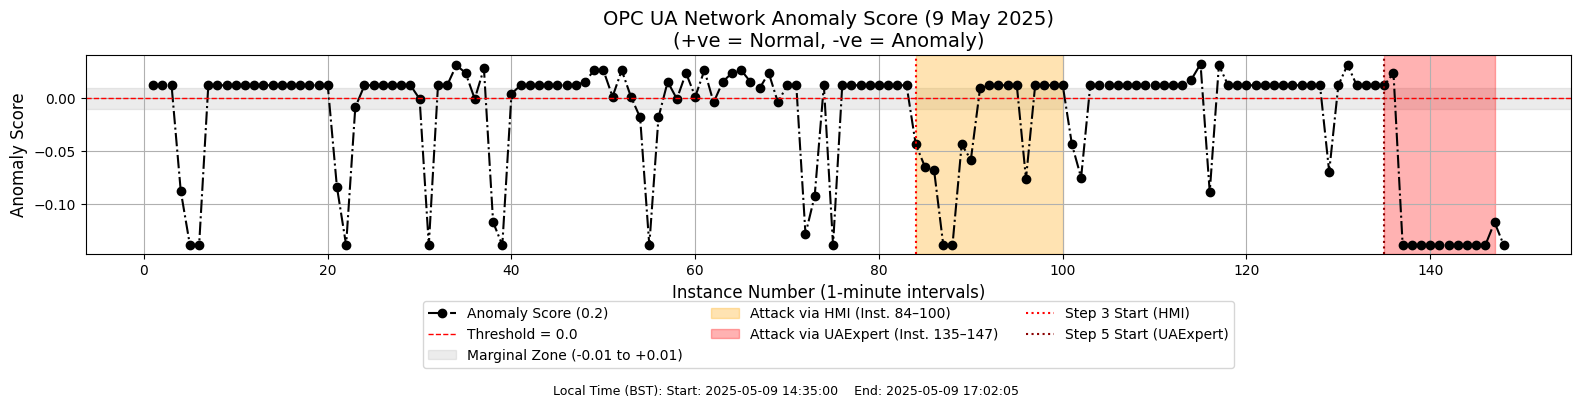

In [59]:
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

# Create plot
plt.figure(figsize=(16, 4))
plt.plot(instance_summary_09May['instance'], instance_summary_09May['anomaly_score_0.2'],
         label='Anomaly Score (0.2)', color='black', marker='o', linestyle='-.')

# Horizontal threshold and marginal band
plt.axhline(y=0.0, color='red', linestyle='--', linewidth=1, label='Threshold = 0.0')
plt.axhspan(-0.01, 0.01, color='gray', alpha=0.15, label='Marginal Zone (-0.01 to +0.01)')

# Attack periods (x-axis = instance number)
plt.axvspan(84, 100, color='orange', alpha=0.3, label='Attack via HMI (Inst. 84–100)')
plt.axvspan(135, 147, color='red', alpha=0.3, label='Attack via UAExpert (Inst. 135–147)')
plt.axvline(x=84, color='red', linestyle=':', linewidth=1.5, label='Step 3 Start (HMI)')
plt.axvline(x=135, color='darkred', linestyle=':', linewidth=1.5, label='Step 5 Start (UAExpert)')

# Axis labels and title
plt.title("OPC UA Network Anomaly Score (9 May 2025)\n(+ve = Normal, -ve = Anomaly)", fontsize=14)
plt.xlabel("Instance Number (1-minute intervals)", fontsize=12)
plt.ylabel("Anomaly Score", fontsize=12)
plt.grid(True)

# Timestamp legend
first_ts = df_09May['ts'].min()
last_ts = df_09May['ts'].max()

first_ts_local = first_ts.tz_localize('UTC').astimezone(ZoneInfo('Europe/London'))
last_ts_local = last_ts.tz_localize('UTC').astimezone(ZoneInfo('Europe/London'))
plt.figtext(0.5, -0.001,
            f"Local Time (BST): Start: {first_ts_local.strftime('%Y-%m-%d %H:%M:%S')}    "
            f"End: {last_ts_local.strftime('%Y-%m-%d %H:%M:%S')}",
            horizontalalignment='center', fontsize=9)

# Legend and layout
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=10)
plt.tight_layout()
plt.show()

In [60]:
# Define interpretation function
def interpret_anomaly(score):
    if score < -0.01:
        return 'Network - Anomaly'
    elif score > 0.01:
        return 'Network - Normal'
    else:
        return 'Network - Marginal'

# Apply classification
instance_summary_09May['Network_Label_3Class'] = instance_summary_09May['anomaly_score_0.2'].apply(interpret_anomaly)

# Display some results
instance_summary_09May[['anomaly_score_0.2', 'Network_Label_3Class']].head()

,anomaly_score_0.2,Network_Label_3Class
0,0.012531,Network - Normal
1,0.012531,Network - Normal
2,0.012531,Network - Normal
3,-0.087744,Network - Anomaly
4,-0.139128,Network - Anomaly


In [61]:
instance_summary_09May['Network_Label_3Class'].value_counts()

,count
Network_Label_3Class,
Network - Normal,98
Network - Anomaly,38
Network - Marginal,12


In [62]:
instance_summary_09May['Network_Label_3Class'].value_counts(normalize=True) * 100

,proportion
Network_Label_3Class,
Network - Normal,66.216216
Network - Anomaly,25.675676
Network - Marginal,8.108108


# Step 6 - List of Anomalies for investigation

In [121]:
# Identify anomalous instances
anomalous_instances = instance_summary_09May[instance_summary_09May['anomaly_0.2'] == -1]['instance'].tolist()

In [135]:
# Filter Original Dataset for Those Instances
df_anomalous_network = df_09May[df_09May['instance'].isin(anomalous_instances)]

In [136]:
def explain_network_anomalies(df):
    explanations = []
    grouped = df.groupby('instance')

    for instance, group in grouped:
        ts = group['ts'].min()
        nodes = group['node_id_string'].dropna().unique().tolist()
        ports = group['id.orig_p'].dropna().unique().tolist()
        msg_sizes = group['msg_size'].dropna().unique().tolist()

        explanations.append({
            'timestamp': ts.strftime('%Y-%m-%d %H:%M'),
            'instance': instance,
            'node_ids_written': ', '.join(nodes[:5]),
            'source_ports': ', '.join(map(str, ports[:5])),
            'message_sizes': ', '.join(map(str, msg_sizes[:5])),
            'explanation': 'Unusual OPC UA write pattern detected'
        })

    return pd.DataFrame(explanations)

In [138]:
df_network_explanations['timestamp'] = pd.to_datetime(df_network_explanations['timestamp'])
df_network_explanations['timestamp_bst'] = pd.to_datetime(df_network_explanations['timestamp_bst'])

def print_simple_network_log(df):
    for _, row in df.iterrows():
        utc_str = row['timestamp'].strftime('%Y-%m-%d %H:%M')
        bst_str = row['timestamp_bst'].strftime('%Y-%m-%d %H:%M')
        print(f"Anomalous OPC UA write patterns noted at {utc_str} (UTC Time) / {bst_str} (Local Time)")

        if row['node_ids_written'] and row['node_ids_written'].strip() != '-':
            print(f"Explanation: OPC UA write to node(s): {row['node_ids_written']}")

        print('-' * 60)

In [140]:
df_network_explanations

,timestamp,instance,node_ids_written,source_ports,message_sizes,explanation,anomaly_score,timestamp_bst
0,2025-05-09 13:38:00,4,-,"53373, 53218","253, 100, 204, 189, 1584",Unusual OPC UA write pattern detected,-0.087744,2025-05-09 14:38:00+01:00
1,2025-05-09 13:39:00,5,-,"53373, 53218","253, 100, 204, 189, 255",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 14:39:00+01:00
2,2025-05-09 13:40:00,6,-,"53373, 53218","253, 100, 204, 189, 1558",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 14:40:00+01:00
3,2025-05-09 13:55:00,21,-,"53373, 53218","253, 100, 204, 189, 1584",Unusual OPC UA write pattern detected,-0.084002,2025-05-09 14:55:00+01:00
4,2025-05-09 13:56:00,22,-,"53373, 53218","253, 100, 204, 189, 1558",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 14:56:00+01:00
5,2025-05-09 13:57:00,23,-,"53373, 53218","253, 100, 204, 189, 1558",Unusual OPC UA write pattern detected,-0.008339,2025-05-09 14:57:00+01:00
6,2025-05-09 14:04:00,30,-,"53373, 53218","253, 100, 204, 189, 96",Unusual OPC UA write pattern detected,-0.000419,2025-05-09 15:04:00+01:00
7,2025-05-09 14:05:00,31,-,"53373, 53218","96, 74, 1582, 66, 414",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 15:05:00+01:00
8,2025-05-09 14:10:00,36,-,"53373, 53218","253, 100, 204, 189, 1682",Unusual OPC UA write pattern detected,-0.000419,2025-05-09 15:10:00+01:00
9,2025-05-09 14:12:00,38,-,"53373, 53218","253, 100, 204, 189, 1584",Unusual OPC UA write pattern detected,-0.117374,2025-05-09 15:12:00+01:00


In [141]:
# Export to CSV
df_network_explanations.to_csv('opcua_network_anomalies_09May.csv', index=False)

In [130]:
print_simple_network_log(df_network_explanations)

Anomalous OPC UA write patterns noted at 2025-05-09 13:38 (UTC Time) / 2025-05-09 14:38 (Local Time)
------------------------------------------------------------
Anomalous OPC UA write patterns noted at 2025-05-09 13:39 (UTC Time) / 2025-05-09 14:39 (Local Time)
------------------------------------------------------------
Anomalous OPC UA write patterns noted at 2025-05-09 13:40 (UTC Time) / 2025-05-09 14:40 (Local Time)
------------------------------------------------------------
Anomalous OPC UA write patterns noted at 2025-05-09 13:55 (UTC Time) / 2025-05-09 14:55 (Local Time)
------------------------------------------------------------
Anomalous OPC UA write patterns noted at 2025-05-09 13:56 (UTC Time) / 2025-05-09 14:56 (Local Time)
------------------------------------------------------------
Anomalous OPC UA write patterns noted at 2025-05-09 13:57 (UTC Time) / 2025-05-09 14:57 (Local Time)
------------------------------------------------------------
Anomalous OPC UA write patte

In [142]:
def generate_network_log(df):
    logs = []
    for _, row in df.iterrows():
        utc_str = row['timestamp'].strftime('%Y-%m-%d %H:%M')
        bst_str = row['timestamp_bst'].strftime('%Y-%m-%d %H:%M')
        logs.append(f"Anomalous OPC UA write patterns noted at {utc_str} (UTC Time) / {bst_str} (Local Time)")
        if row['node_ids_written'] and row['node_ids_written'].strip() != '-':
            logs.append(f"Explanation: OPC UA write to node(s): {row['node_ids_written']}")
        logs.append('-' * 60)
    return logs

In [149]:
log_lines = generate_network_log(df_network_explanations)

with open("network_anomaly_log_09May.txt", "w") as f:
    for line in log_lines:
        f.write(line + "\n")


The end